# Building Classifiers from Scratch
## Logistic Regression, SVM, Decision Trees, and KNN

### Why Build from Scratch?

In Part 2, we built Perceptron and Adaline from scratch. Now we'll extend this approach to the **5 core classifiers** from Part 3:

1. **Logistic Regression** — modeling probabilities with gradient descent
2. **SVM (Linear)** — maximum margin classification
3. **Decision Tree** — recursive splitting with information gain
4. **K-Nearest Neighbors** — lazy learning with distance metrics
5. **SVM (RBF)** — kernel trick for non-linear boundaries

### Why This Matters

Implementing algorithms from scratch reveals the **hidden mechanics** that black-box libraries hide:
- How gradient descent actually updates weights
- How decision trees choose splits
- Why feature scaling is critical for some algorithms
- How the kernel trick works under the hood

**Think of it like learning to drive a manual car before an automatic** — you'll understand the engine, clutch, and gears, making you a better driver overall.

## 1. Setup and Data Loading

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

In [20]:
data = load_iris()
X = data.data[:100, [0, 2]] # only 2 features and 2 iris types
y = data.target[:100]

y = np.where(y == 0, -1, 1)

In [21]:
display(f"Data shape: {X.shape}")
display(f"Labels: {np.unique(y)}")

'Data shape: (100, 2)'

'Labels: [-1  1]'

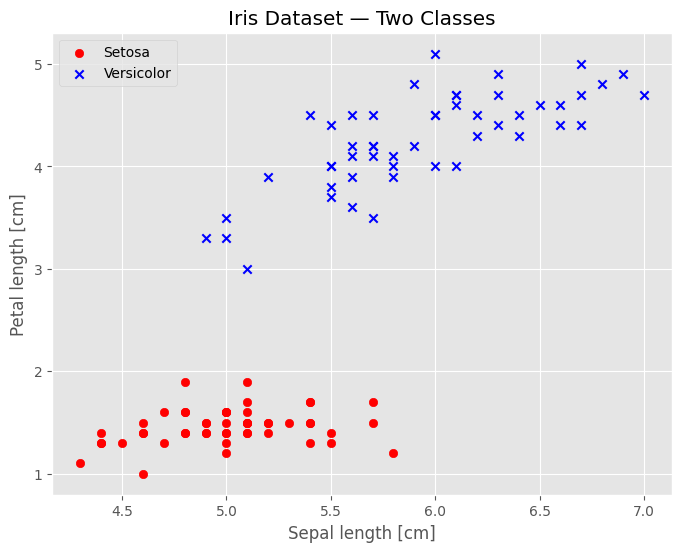

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == -1, 0], X[y == -1, 1],
            color='red', marker='o', label='Setosa')
plt.scatter(X[y == 1, 0], X[y == 1, 1],
            color='blue', marker='x', label='Versicolor')
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.title('Iris Dataset — Two Classes')
plt.show()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

## 2. Logistic Regression from Scratch


### The Math Behind Logistic Regression

**The Core Idea**: Instead of predicting a class directly, we predict the **probability** of belonging to class 1.

**Step 1**: Compute the linear combination $z = \mathbf{w}^T\mathbf{x} + b$

**Step 2**: Pass through the **sigmoid function** $\sigma(z) = \frac{1}{1 + e^{-z}}$

**Step 3**: Interpret $\sigma(z)$ as $P(y=1 \mid \mathbf{x})$

**Step 4**: Train by minimizing the **log-loss (cross-entropy)**:

$$
J(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y^{(i)} \log(\sigma(z^{(i)})) + (1-y^{(i)}) \log(1-\sigma(z^{(i)})) \right]
$$

**Why log-loss instead of MSE?** Log-loss is **convex** — it has a single global minimum. MSE for logistic regression is non-convex (multiple local minima).

**Gradient of log-loss** (derived using the chain rule):

$$
\nabla J(\mathbf{w}) = \frac{1}{n} \mathbf{X}^T (\sigma(\mathbf{z}) - \mathbf{y})
$$

**Update rule**: $\mathbf{w} := \mathbf{w} - \eta \cdot \nabla J(\mathbf{w})$

In [24]:
class LogisticRegressionGD:
    """
    Logistic Regression using batch gradient descent.

    Parameters:
    -----------
    eta : float, learning rate
    n_iter : int, number of epochs
    random_state : int, seed for reproducibility

    Attributes:
    -----------
    w_ : 1d-array, weights after training
    b_ : float, bias term
    losses_ : list, log-loss per epoch
    """
    def __init__(self, eta=0.01, n_epochs=50, random_seed=42):
        self.eta = eta
        self.n_epochs = n_epochs
        self.random_seed = random_seed

    def _compute_net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def _sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1. / (1. + np.exp(-z))

    def _loss(self, y_pred, y_true):
        y_pred = np.clip(y_pred, 0 + 1e-15, 1 - 1e-15)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        rgen = np.random.RandomState(self.random_seed)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=n_features)
        self.b_ = np.float32(0.)
        self.losses_ = []

        y = np.where(y == -1, 0, y)
        y = np.astype(y, np.float32)

        for i in range(self.n_epochs):
            net_input = self._compute_net_input(X)
            preds = self._sigmoid(net_input)
            errors = preds - y
            self.w_ -= self.eta * (1 / n_samples) * np.dot(X.T, errors)
            self.b_ -= self.eta * (1 / n_samples) * np.sum(errors)

            loss = self._loss(preds, y)
            self.losses_.append(loss)

    def predict_proba(self, X):
        return self._sigmoid(self._compute_net_input(X))

    def predict(self, X):
        return np.where(self.predict_proba(X) >= 0.5, 1, -1)

### Train Our Custom Logistic Regression

In [25]:
lr_custom = LogisticRegressionGD(eta=0.01, n_epochs=100)
lr_custom.fit(X_train, y_train)

In [26]:
custom_lr_preds = lr_custom.predict(X_test)
custom_lr_accur = accuracy_score(y_test, custom_lr_preds)
print(custom_lr_accur)

1.0


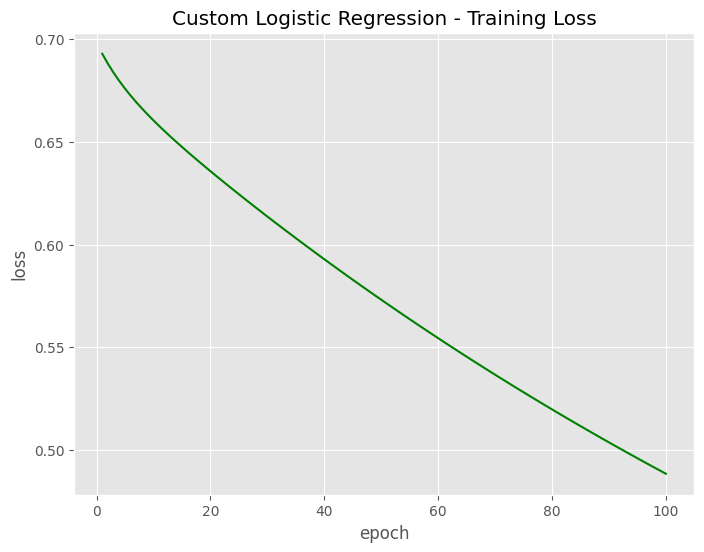

In [27]:
plt.style.use('ggplot')

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(lr_custom.losses_) + 1), lr_custom.losses_, color='green')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title('Custom Logistic Regression - Training Loss')
plt.grid(True)
plt.show()

### Comparison with Scikit-Learn's Implementation

In [28]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegressionGD(eta=0.01, n_epochs=100)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_accur = accuracy_score(y_test, lr_pred)

print(f"Native logistic regression accuracy: {(lr_accur * 100):.2f}%")

print("\nWeight Comparison:")
print(f"Custom weights: {lr_custom.w_}")
print(f"Sklearn weights: {lr.w_}")

Native logistic regression accuracy: 100.00%

Weight Comparison:
Custom weights: [-0.15095822  0.40707152]
Sklearn weights: [-0.15095822  0.40707152]


## 3. Support Vector Machine (Linear) from Scratch

## Linear SVM Math

## Core Idea

Find the hyperplane that **maximizes the margin** between classes.  
The decision function is:

$$
f(x) = \langle w, x \rangle + b
$$

## Visualization

![Basic concept](https://habrastorage.org/r/w1560/webt/n-/5u/gy/n-5ugyyyqejoobj9javfcxaycpk.png)

![Basic concept 1](https://habrastorage.org/r/w1560/webt/5s/g-/k9/5sg-k9ytduiqgxlsv66u6jprvsi.png)

## Margin for a Sample

For a sample $x_i$ with label $y_i \in \{-1, +1\}$, the margin is:

$$
M_i = y_i \bigl( \langle w, x_i \rangle + b \bigr)
$$

- If $M_i > 0$ → correctly classified.
- The larger $M_i$, the more confident the prediction.

## Hard Margin (linearly separable)

We require **all** samples to be outside the margin strip:

$$
M_i \ge 1 \quad \forall i
$$

## Soft Margin (non‑separable case)

Allow some violations by introducing **slack variables** $\xi_i \ge 0$:

$$
y_i \bigl( \langle w, x_i \rangle + b \bigr) \ge 1 - \xi_i, \qquad \xi_i \ge 0
$$

## Primal Objective (Soft Margin)

Minimize the sum of the squared norm of weights plus a penalty for violations:

$$
\min_{w,b,\xi} \left( \frac{1}{2} \|w\|^2 + C \sum_{i} \xi_i \right)
$$

- $C$ is a hyperparameter that controls the trade‑off between margin width and misclassification.

## Hinge Loss (unconstrained form)

The unconstrained equivalent uses the **Hinge Loss**:

$$
L(y, f) = \max(0, \, 1 - y \cdot f)
$$

The total cost (with regularization) is:

$$
J(w,b) = \frac{1}{n} \sum_{i=1}^n \max\bigl(0, \, 1 - y_i(\langle w, x_i \rangle + b)\bigr) + \frac{C}{2} \|w\|^2
$$

## Gradients (subgradients)

Gradient w.r.t. $w$:

$$
\frac{\partial J}{\partial w} = C \cdot w - \frac{1}{n} \sum_{i: M_i < 1} y_i x_i
$$

Gradient w.r.t. $b$:

$$
\frac{\partial J}{\partial b} = - \frac{1}{n} \sum_{i: M_i < 1} y_i
$$

**Important:** Only samples with margin $M_i < 1$ (violations or support vectors) contribute to the gradient.

## Gradient Descent Update

At each iteration:

$$
w := w - \eta \cdot \frac{\partial J}{\partial w}, \qquad b := b - \eta \cdot \frac{\partial J}{\partial b}
$$

where $\eta$ is the learning rate.

In [29]:
class SVMGD:
    """
    Linear SVM trained with batch gradient descent on Hinge loss.

    Parameters:
    -----------
    eta : float, learning rate
    n_epochs : int
    C : float, regularization strength
    random_seed : int

    Attributes:
    -----------
    w_ : weights
    b_ : bias
    losses_ : list of average loss per epoch
    """
    def __init__(self, eta=0.01, n_epochs=50, C=1, random_seed=42):
        self.eta = eta
        self.n_epochs = n_epochs
        self.C = C
        self.random_seed = random_seed

        self.losses_ = []
        self.w_ = None
        self.b_ = None

    def _hinge_loss(self, X, y):
        return (1 / X.shape[0]) * np.sum(np.maximum(0, 1 - y * (X @ self.w_ + self.b_))) +\
        self.C * 0.5 * np.sum(self.w_ ** 2)

    def _calc_grads(self, X, y):
        n = X.shape[0]
        margin = y * (X @ self.w_ + self.b_)
        violations = np.astype((margin < 1), np.int32)
        grad_w = self.C * self.w_ - (1 / n) * (X.T @ (y * violations))
        grad_b = -(1 / n) * np.sum(y * violations)
        return grad_w, grad_b

    def fit(self, X, y):
        n_samples, n_features = X.shape
        rgen = np.random.RandomState(self.random_seed)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=n_features)
        self.b_ = np.float32(0.)

        for epoch in range(1, self.n_epochs + 1):
            grad_w, grad_b = self._calc_grads(X, y)
            self.w_ -= self.eta * grad_w
            self.b_ -= self.eta * grad_b
            loss = self._hinge_loss(X, y)
            self.losses_.append(loss)

        return self

    def get_estimation(self, X):
        return X @ self.w_ + self.b_

    def predict(self, X):
        signs = np.sign(self.get_estimation(X))
        preds = np.where(signs >= 0, 1, -1)
        return preds

### Train Our Custom Linear SVM

In [30]:
svm_custom = SVMGD(eta=0.01, n_epochs=200, C=1.0, random_seed=42)
svm_custom.fit(X_train, y_train)
y_pred_svm_custom = svm_custom.predict(X_test)
acc_svm_custom = accuracy_score(y_test, y_pred_svm_custom)

print(f"Custom SVM accuracy:  {acc_svm_custom*100:.2f}%")

Custom SVM accuracy:  100.00%


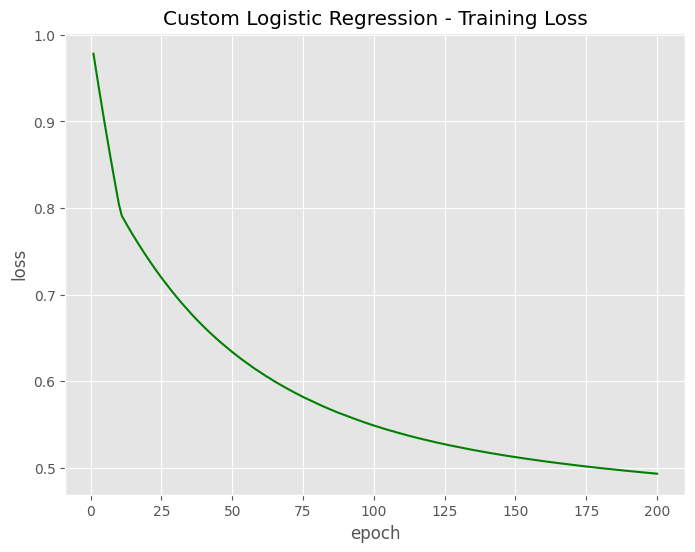

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(svm_custom.losses_) + 1), svm_custom.losses_, color='green')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title('Custom Logistic Regression - Training Loss')
plt.grid(True)
plt.show()

### Comparison with Scikit-Learn's SVM

In [32]:
from sklearn.svm import SVC

svm_sklearn = SVC(kernel='linear', C=1.0, random_state=42)
svm_sklearn.fit(X_train, y_train)
y_pred_sklearn = svm_sklearn.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Sklearn SVM accuracy: {acc_sklearn*100:.2f}%")

Sklearn SVM accuracy: 100.00%


In [33]:
print(f"Custom: w={svm_custom.w_}, b={svm_custom.b_:.4f}")
print(f"Sklearn: w={svm_sklearn.coef_[0]}, b={svm_sklearn.intercept_[0]:.4f}")

Custom: w=[-0.28639714  0.66206741], b=-0.2552
Sklearn: w=[0.01846166 1.2476933 ], b=-3.4592


## 4. Decision Tree from Scratch

# Decision Trees: Theory and Implementation

## 1. The Math Behind Decision Trees

### Core Idea

Decision trees learn a hierarchy of **if‑else** questions from the data. At each node, we select a feature and a threshold such that the resulting child nodes are as **pure** as possible (i.e., contain mostly one class). The process is **recursive** and continues until a stopping criterion is met.

**Key steps:**
- For each feature and each possible threshold, evaluate the quality of the split.
- Choose the split that **maximises** the reduction in impurity (or **information gain**).
- Recursively repeat for each child node.

---

### Impurity Measures

An impurity measure quantifies how "mixed" the classes are in a node. Lower impurity means more homogeneity.

#### 1. Gini Impurity (used by CART)

For a node \( t \) with class probabilities \( p_k \) (for \( k = 1, \dots, K \)):

$$
G(t) = 1 - \sum_{k=1}^{K} p_k^2
$$

- **Pure node**: one class has \( p=1 \), others 0 → \( G = 0 \).
- **Maximum impurity**: all classes equally likely → \( G = 1 - 1/K \).  
  For binary classification (\( K=2 \)), max is 0.5.

#### 2. Entropy (used by ID3, C4.5)

$$
H(t) = - \sum_{k=1}^{K} p_k \log_2 p_k
$$

- **Pure node**: \( H = 0 \).
- **Maximum impurity** (uniform distribution) → \( H = \log_2 K \).  
  For binary, max is 1.0.

#### 3. Misclassification Error

$$
E(t) = 1 - \max_k p_k
$$

Often used as a stopping criterion, not for splitting (less sensitive to changes).

**Comparison (binary case):**

| Impurity | Pure | Max (50/50) |
|:---|:---|:---|
| Gini | 0 | 0.5 |
| Entropy | 0 | 1.0 |
| Misclassification | 0 | 0.5 |

> In practice, Gini and Entropy yield similar trees; Gini is slightly faster to compute.

---

### Information Gain

The reduction in impurity after a split is called **Information Gain**:

$$
IG(D, f, t) = I(D) - \frac{|D_{\text{left}}|}{|D|} I(D_{\text{left}}) - \frac{|D_{\text{right}}|}{|D|} I(D_{\text{right}})
$$

where:
- \( I(D) \) is the impurity of the parent node.
- \( D_{\text{left}} \) and \( D_{\text{right}} \) are the subsets after splitting on feature \( f \) at threshold \( t \).

The algorithm searches over all features and all possible thresholds to **maximise** \( IG \).

---

### Handling Continuous Features

For a continuous feature, we sort the unique values and consider candidate thresholds as the **mid‑points** between consecutive distinct values. For each candidate, we evaluate the information gain and pick the best.

---

### Stopping Criteria & Pruning

To prevent overfitting, we impose:

- **Max depth**: limit how deep the tree can grow.
- **Min samples per split**: do not split if fewer samples.
- **Min impurity decrease**: only split if the gain exceeds a threshold.
- **Max leaf nodes**: restrict the total number of leaves.

**Pruning** (post‑training) can further reduce overfitting, but we keep it simple in our implementation.

---

## 2. Implementation: `DecisionTree`

We implement a binary tree with:
- Support for **Gini** and **Entropy**.
- Configurable max depth, min samples per split, min impurity decrease.
- Prediction by majority vote at leaves.

### The `Node` Class

We define a simple node structure storing:
- split feature and threshold
- left and right children
- predicted class (if leaf)
- impurity and number of samples.

```python
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 value=None, impurity=None, n_samples=None):
        self.feature = feature          # index of the feature used for split
        self.threshold = threshold      # threshold value
        self.left = left                # left child node
        self.right = right              # right child node
        self.value = value              # predicted class (if leaf)
        self.impurity = impurity        # impurity at this node
        self.n_samples = n_samples      # number of samples in this node
```

In [34]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 value=None, impurity=None, n_samples=None):
        self.feature = feature          # index of the feature used for split
        self.threshold = threshold      # threshold value
        self.left = left                # left child node
        self.right = right              # right child node
        self.value = value              # predicted class (if leaf)
        self.impurity = impurity        # impurity at this node
        self.n_samples = n_samples      # number of samples in this node

In [51]:
class CustomDecisionTree:
    """
    Decision Tree classifier for binary classification.

    Parameters:
    -----------
    max_depth : int, max depth of the tree
    min_samples_split : int, min samples required to split
    min_impurity_decrease : float, minimum information gain to perform split
    criterion : str, 'gini' or 'entropy'
    """
    def __init__(self, max_depth=None, min_samples_split=2,
                 min_impurity_decrease=0.0, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_impurity_decrease = min_impurity_decrease
        self.criterion = criterion
        self.root = None
        self.n_features = None

    def _impurity(self, y):
        n_unique = len(np.unique(y))
        if n_unique == 1 or len(y) == 0:
            return 0

        counts = np.bincount(y)
        probs = counts / len(y)
        if self.criterion == "gini":
            return 1 - np.sum(probs ** 2)

        elif self.criterion == "entropy":
            return -np.sum(probs * np.log2(probs + 1e-15))

        else:
            raise ValueError("Unsupported criterion")

    def _information_gain(self, y, y_left, y_right):
        p_left = len(y_left) / len(y)
        p_right = len(y_right) / len(y)
        return self._impurity(y) - p_left * self._impurity(y_left) - p_right * self._impurity(y_right)

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = -1.0
        best_feature = None
        best_threshold = None
        best_left_idx = None
        best_right_idx = None

        if len(np.unique(y)) <= 1 or len(y) < self.min_samples_split:
            return None, None, None, None, -1

        parent_impurity = self._impurity(y)

        for feature in range(n_features):
            unique_values = np.unique(X[:, feature])
            if len(unique_values) <= 1:
                continue
            thresholds = (unique_values[:-1] + unique_values[1:]) / 2.0

            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                y_left = y[left_mask]
                y_right = y[right_mask]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gain = self._information_gain(y, y_left, y_right)
                if gain < self.min_impurity_decrease:
                    continue

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
                    best_left_idx = np.where(left_mask)[0]
                    best_right_idx = np.where(right_mask)[0]

        return best_feature, best_threshold, best_left_idx, best_right_idx, best_gain

    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        if (self.max_depth is not None and self.max_depth <= depth) or \
        (len(y) < self.min_samples_split) or \
        (len(np.unique(y)) == 1):
            value = np.bincount(y).argmax()
            return Node(impurity=self._impurity(y), n_samples=n_samples, value=value)

        feature, threshold, left_idx, right_idx, gain = self._best_split(X, y)
        if (feature is None) or (gain < self.min_impurity_decrease):
            value = np.bincount(y).argmax()
            return Node(impurity=self._impurity(y), n_samples=n_samples, value=value)

        left_node = self._build_tree(X[left_idx], y[left_idx], depth+1)
        right_node = self._build_tree(X[right_idx], y[right_idx], depth+1)

        return Node(feature=feature, threshold=threshold, left=left_node, right=right_node,
            impurity=self._impurity(y), n_samples=n_samples)

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        if len(self.classes_) > 2:
            raise ValueError("Only binary classification supported.")
        y = np.where(y == -1, 0, y)
        self.root = self._build_tree(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        if self.root is None:
            raise ValueError("Model not trained yet")
        else:
            preds = np.array([self._predict_one(x, self.root) for x in X])
            preds = np.where(preds == 0, -1, preds)
            return preds

    def _print_tree(self, node, depth=0):
        if node.value is not None:
            print("  " * depth + f"Leaf: class {node.value} (n={node.n_samples}, imp={node.impurity:.3f})")
            return
        print("  " * depth + f"Feature {node.feature} <= {node.threshold:.3f} (n={node.n_samples}, imp={node.impurity:.3f})")
        self._print_tree(node.left, depth + 1)
        self._print_tree(node.right, depth + 1)

    def print_tree(self):
        if self.root is not None:
            self._print_tree(self.root)
        else:
            print("Tree is empty.")

### Train Our Custom Decision Tree

In [52]:
dt_custom = CustomDecisionTree()
dt_custom.fit(X_train, y_train)
dt_custom_pred = dt_custom.predict(X_test)
dt_custom_accuracy = accuracy_score(y_test, dt_custom_pred)

print(f"Decision Tree Custom accuracy: {dt_custom_accuracy}")

Decision Tree Custom accuracy: 1.0


In [53]:
dt_custom.print_tree()

Feature 1 <= 2.450 (n=80, imp=0.500)
  Leaf: class 0 (n=40, imp=0.000)
  Leaf: class 1 (n=40, imp=0.000)


### Comparison with Scikit-Learn's Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier

dt_sklearn = DecisionTreeClassifier()
dt_sklearn.fit(X_train, y_train)
dt_sklearn_pred = dt_sklearn.predict(X_train)
dt_sklearn_accuracy = accuracy_score(y_test, dt_custom_pred)

print(f"Decision Tree Sklearn accuracy: {dt_sklearn_accuracy:.2f}")

Decision Tree Sklearn accuracy: 1.00


## K‑Nearest Neighbors (KNN)

### Core Idea

**K‑Nearest Neighbors (KNN)** is one of the simplest machine learning algorithms. It belongs to the class of **lazy learners** – it does not build an explicit model during training; instead, it stores the entire training dataset. Predictions are made at query time by comparing the new sample to all stored examples.

**Algorithm steps:**
1. Store all training samples.
2. For each test sample, compute the distance to every training sample.
3. Select the **k** closest neighbors (those with the smallest distances).
4. Assign the class that appears most frequently among the k neighbors (or use weighted voting).

### Distance Metrics

The choice of distance metric defines what "close" means. The most common choices are:

- **Euclidean distance** (L2):
  $$
  d(x, x') = \sqrt{\sum_{j=1}^{d} (x_j - x'_j)^2}
  $$
- **Manhattan distance** (L1):
  $$
  d(x, x') = \sum_{j=1}^{d} |x_j - x'_j|
  $$
- **Minkowski distance** (generalisation):
  $$
  d(x, x') = \left( \sum_{j=1}^{d} |x_j - x'_j|^p \right)^{1/p}
  $$
  where \(p=2\) gives Euclidean, \(p=1\) gives Manhattan.

The choice of metric depends on the data. Euclidean distance works well when features are in the same scale and have similar importance; Manhattan distance is more robust to outliers.

### Choosing the Parameter k

The number of neighbors \(k\) is the main hyperparameter.

- **Small \(k\)** (e.g., 1): the model is sensitive to noise, the decision boundary is highly irregular → **overfitting**.
- **Large \(k\)**: the boundary becomes smoother, but local structure may be lost → **underfitting**.

The optimal \(k\) is typically found via validation (e.g., cross‑validation). For binary classification, an odd \(k\) is often chosen to avoid ties.

### Weighted Voting

Instead of simple majority, we can assign **weights** to each neighbor based on its distance: closer neighbors have greater influence. A common weight is \(w = 1/d\) (or \(w = 1/(d+\varepsilon)\) to avoid division by zero). This often improves performance because distant neighbors contribute less.

### Feature Scaling

KNN is highly sensitive to the **scale** of features because distances are computed across all dimensions. If one feature ranges from 0 to 1000 and another from 0 to 1, the first will dominate the distance and the algorithm will effectively ignore the others.

**Therefore, scaling (normalisation) is essential** before applying KNN:
- Standardisation (z‑score): \(x' = \frac{x - \mu}{\sigma}\)
- Min‑max normalisation: \(x' = \frac{x - \min}{\max - \min}\)

### Advantages and Disadvantages

| Advantages | Disadvantages |
|:---|:---|
| Simple to implement and interpret. | High computational cost at prediction time (O(n·d) per query). |
| Makes no assumptions about data distribution (non‑parametric). | Sensitive to outliers and noise. |
| Naturally handles multi‑class problems. | Requires storing the entire training set (memory intensive). |
| Can be used for both classification and regression. | Curse of dimensionality: as the number of features grows, distances become less discriminative. |

In [80]:
from collections import Counter

class KNN:
    """
    K-Nearest Neighbors classifier.

    Parameters:
    -----------
    n_neighbors : int, number of neighbors to consider (default 5)
    metric : str, distance metric ('euclidean' or 'manhattan')
    weights : str, voting scheme ('uniform' or 'distance')
    """
    def __init__(self, n_neighbors=5, metric='euclidean', weights='uniform'):
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.weights = weights

    def _distance(self, X1, X2):
        if self.metric == "euclidean":
            diff = X1[:, None, :] - X2[None, :, :]
            sq_dist = np.sum(diff**2, axis=2)
            return np.sqrt(np.maximum(sq_dist, 0))
        elif self.metric == "manhattan":
            return np.sum(np.abs(X1[:, None, :] - X2[None, :, :]), axis=2)
        else:
            raise ValueError("Not supported this distance")

    def fit(self, X, y):
        self.X_ = X
        self.y_ = y
        return self

    def predict(self, X):
        if self.X_ is None:
            raise ValueError("Model not trained")

        distances = self._distance(X, self.X_)
        top_k_idx = np.argsort(distances, axis=1)[:, :self.n_neighbors]
        top_k = self.y_[top_k_idx]

        if self.weights == "uniform":
            preds = []
            for row in top_k:
                counts = Counter(row)
                preds.append(counts.most_common(1)[0][0])
            return np.array(preds)

        elif self.weights == 'distance':
            neighbor_dist = distances[np.arange(X.shape[0])[:, None], top_k_idx]
            weights = 1.0 / (neighbor_dist + 1e-15)

            preds = []
            for labels, w in zip(top_k, weights):
                class_weights = {}
                for lab, wt in zip(labels, w):
                    class_weights[lab] = class_weights.get(lab, 0.0) + wt
                preds.append(max(class_weights, key=class_weights.get))
            return np.array(preds)

        else:
            raise ValueError("Unsupported weights scheme")

### Train Our Custom KNN

In [81]:
knn_custom = KNN()
knn_custom.fit(X_train, y_train)
knn_custom_preds = knn_custom.predict(X_test)
knn_custom_accuracy = accuracy_score(y_test, knn_custom_preds)

print(f"Custom KNN accuracy: {knn_custom_accuracy:.2f}")

Custom KNN accuracy: 1.00


### Comparison with Scikit-Learn's KNN

In [82]:
from sklearn.neighbors import KNeighborsClassifier

knn_sklearn = KNeighborsClassifier()
knn_sklearn.fit(X_train, y_train)
knn_sklearn_preds = knn_sklearn.predict(X_test)
knn_sklearn_accuracy = accuracy_score(y_test, knn_sklearn_preds)

print(f"KNN Sklearn accuracy: {knn_sklearn_accuracy:.2f}")

KNN Sklearn accuracy: 1.00


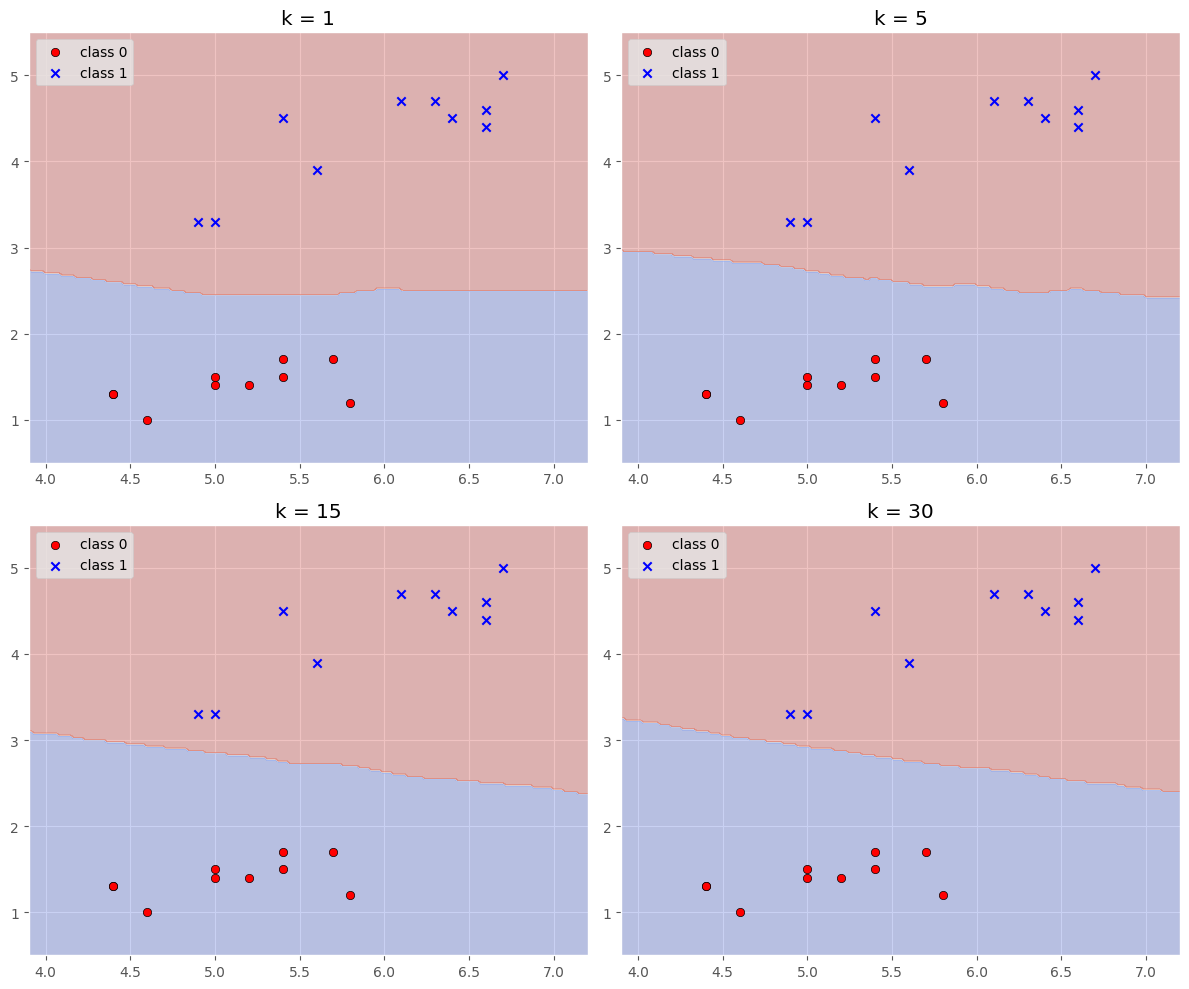

In [85]:
def plot_knn_boundary(X, y, model, title, ax):
    x_min, x_max = X[:,0].min()-.5, X[:,0].max()+.5
    y_min, y_max = X[:,1].min()-.5, X[:,1].max()+.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[y==-1,0], X[y==-1,1], c='red', marker='o', edgecolor='k', label='class 0')
    ax.scatter(X[y==1,0], X[y==1,1], c='blue', marker='x', edgecolor='k', label='class 1')
    ax.set_title(title)
    ax.legend()

k_values = [1, 5, 15, 30]
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()
for i, k in enumerate(k_values):
    model = KNN(n_neighbors=k, metric='euclidean', weights='uniform')
    model.fit(X_train, y_train)
    plot_knn_boundary(X_test, y_test, model, f'k = {k}', axes[i])
plt.tight_layout()
plt.show()